# 🧠 Modern LLM'lerin Kalbi: Self-Attention Mekanizması

Bu notebook, **TF-IDF'ten Self-Attention'a** nasıl evrildiğimizi ve modern Transformer modellerinin **neden RNN'lerden daha iyi** olduğunu kod örnekleriyle açıklamaktadır.

---
## 📌 İçindekiler
1. RNN'nin Temel Sorunu: Uzun Cümlelerde Hafıza Kaybı
2. TF-IDF: Kelimeleri Sayarak Anlamaya Çalışmak
3. Self-Attention: Kelimeler Birbirini Dinliyor
4. Q, K, V Matrisleri — Soru, Anahtar, Değer
5. Multi-Head Attention
6. TF-IDF vs Self-Attention: Karşılaştırma
7. Tam Transformer Encoder Bloğu

### 🎯 Bu Notebook Neyi Anlatıyor?

Bir dil modelinin bir cümledeki kelimeler arasındaki ilişkileri nasıl kurduğu, doğal dil işlemenin en temel sorunlarından biridir. Bu notebook, bu problemin çözümünde yaşanan **tarihsel evrimi** adım adım gösterir:

`Bag of Words → TF-IDF → RNN → Self-Attention → Transformer`

Her yöntem, bir öncekinin eksiğini kapatmak için geliştirilmiştir. TF-IDF bağlamı anlayamaz, RNN uzun cümlelerde hafızasını kaybeder, Self-Attention ise her iki sorunu da çözerek bugünün GPT, BERT, Claude gibi modellerinin temelini oluşturur.


In [1]:
# =============================================================================
# KURULUM: Gerekli kütüphaneleri yükle
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ Kütüphaneler başarıyla yüklendi!')
print(f'NumPy version: {np.__version__}')

✅ Kütüphaneler başarıyla yüklendi!
NumPy version: 2.4.4


---
## 1. RNN'nin Problemi: Uzun Cümlelerde Hafıza Kaybı

RNN (Recurrent Neural Network), cümleyi **soldan sağa** okur. Her adımda bir **gizli durum (hidden state)** taşır.  
Sorun: Cümle uzadıkça, ilk kelimelerin etkisi giderek **azalır ve kaybolur** — buna **vanishing gradient** denir.

```
"Ben dün markete gittim ama istediğim ürünü bulamadım"
  h1   h2    h3      h4    h5      h6       h7         h8
   |→→→|→→→→|→→→→→→→|→→→→|→→→→→→|→→→→→→→→|→→→→→→→→→→|
```
"Ben" kelimesi `h8`'e ulaşana kadar çok zayıflar. 🔴

### 🔁 RNN Nasıl Çalışır?

RNN (Recurrent Neural Network / Tekrarlayan Sinir Ağı), bir cümleyi kelime kelime, soldan sağa okur. Her adımda:

1. O anki kelimeyi işler
2. Önceki adımdan gelen **gizli durumu (hidden state)** ile birleştirir
3. Yeni bir gizli durum üretir ve bir sonraki adıma aktarır

Bu gizli durum, aslında cümlenin o ana kadarki "özeti" gibi davranır. Sorun şurada: her adımda bu özet, ağırlıklarla çarpılıp yeniden şekillendirilir. Cümle uzadıkça, başlangıçtaki kelimelerin bilgisi tekrar tekrar çarpılarak **katlanarak zayıflar** — buna **vanishing gradient (kaybolan gradyan)** problemi denir.

### 📉 Neden Önemli?

"Ben dün markete gittim ama **istediğim ürünü** bulamadım" cümlesinde, "bulamadım" fiilinin öznesi olan "Ben"in etkisi, cümlenin sonuna geldiğimizde neredeyse kaybolmuş olabilir. Bu, RNN'in uzun-mesafeli bağımlılıkları (long-range dependencies) yakalamakta neden zorlandığını açıklar.

LSTM ve GRU gibi "kapılı" (gated) mimariler bu sorunu kısmen azaltır, ama tamamen çözmez — ayrıca kelimeleri **sırayla** işledikleri için paralelleştirilemezler, bu da eğitimi yavaşlatır.


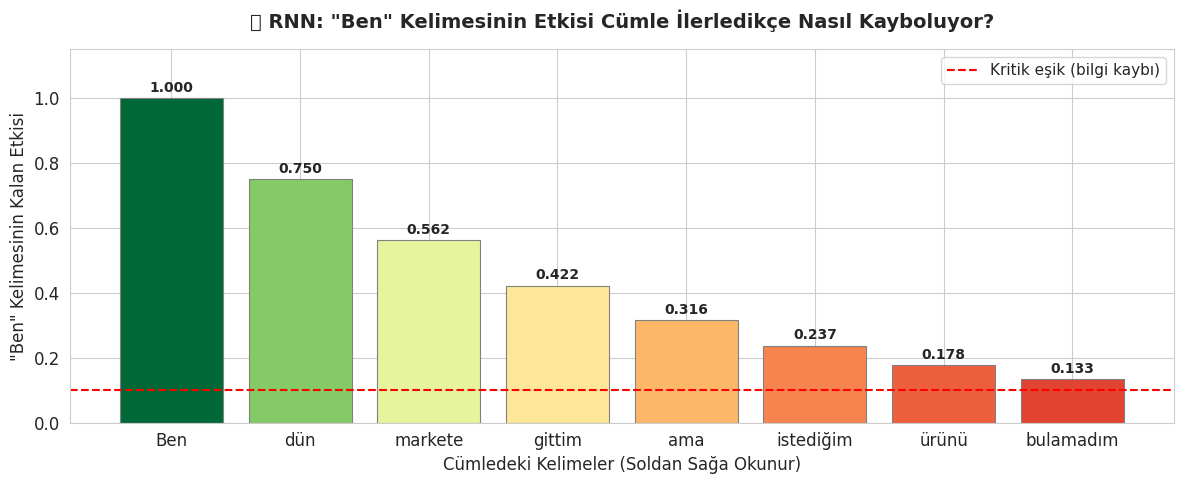

"bulamadım" kelimesine ulaştığında "Ben"in etkisi: 0.1335
Yani bilginin %86.7'ü KAYBOLDU! 😱


In [2]:
# =============================================================================
# RNN'deki HAFIZA KAYBI — Simülasyon
# 
# Burada RNN'nin "sinyali" nasıl zayıflattığını simüle ediyoruz.
# Gerçek bir RNN ağırlıklarla öğrenir, ama etkiyi anlamak için
# her adımda sinyal 0.85 ile çarplıyoruz (bozunma katsayısı).
# =============================================================================

# Örnek cümle
cumle = ["Ben", "dün", "markete", "gittim", "ama", "istediğim", "ürünü", "bulamadım"]

# Bozunma (decay) katsayısı — her adımda sinyal bu kadar zayıflar
bozunma = 0.75

# "Ben" kelimesinin ilk etkisi 1.0 (tam güç)
etki = 1.0
etkiler = []

for kelime in cumle:
    etkiler.append(etki)
    etki *= bozunma  # Her adımda güç azalır

# Görselleştirme
fig, ax = plt.subplots(figsize=(12, 5))

renkler = plt.cm.RdYlGn(np.array(etkiler))  # Kırmızı=zayıf, Yeşil=güçlü
bars = ax.bar(cumle, etkiler, color=renkler, edgecolor='gray', linewidth=0.8)

# Değerleri bar'ların üstüne yaz
for bar, deger in zip(bars, etkiler):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{deger:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('🔴 RNN: "Ben" Kelimesinin Etkisi Cümle İlerledikçe Nasıl Kayboluyor?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cümledeki Kelimeler (Soldan Sağa Okunur)', fontsize=12)
ax.set_ylabel('"Ben" Kelimesinin Kalan Etkisi', fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5, label='Kritik eşik (bilgi kaybı)')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('rnn_hafiza_kaybi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'"bulamadım" kelimesine ulaştığında "Ben"in etkisi: {etkiler[-1]:.4f}')
print(f'Yani bilginin %{(1-etkiler[-1])*100:.1f}\'ü KAYBOLDU! 😱')

---
## 2. TF-IDF: Kelimeleri Sayarak Anlam Çıkarmaya Çalışmak

**TF-IDF** (Term Frequency - Inverse Document Frequency), bir kelimenin **ne kadar önemli** olduğunu iki faktörle ölçer:

| Bileşen | Açıklama | Formül |
|---------|----------|---------|
| **TF** | Kelime bu belgede kaç kez geçiyor? | `count(t,d) / len(d)` |
| **IDF** | Kelime tüm belgelerde ne kadar nadir? | `log(N / df(t))` |

**Problem:** TF-IDF bağlamı anlayamaz! "Banka" kelimesi para mı, nehir kıyısı mı bilmez.

### 🔢 TF-IDF'in Mantığı

TF-IDF, bir kelimenin bir belgede ne kadar "ayırt edici" olduğunu ölçmeye çalışan istatistiksel bir yöntemdir:

- **TF (Term Frequency):** Kelime bu belgede ne kadar sık geçiyor? Sık geçen kelime muhtemelen o belge için önemlidir.
- **IDF (Inverse Document Frequency):** Kelime, tüm belgeler genelinde ne kadar nadir? "ve", "bir" gibi çok yaygın kelimelerin IDF'i düşüktür çünkü ayırt edici değildirler; nadir kelimelerin IDF'i yüksektir.

İkisi çarpılır: `TF-IDF = TF × IDF`. Yüksek TF-IDF skoru, "bu kelime bu belgeye özgü ve önemli" anlamına gelir.

### ⚠️ Temel Kısıtlama: Bağlam Körlüğü

TF-IDF her kelimeyi **bağımsız bir sayım birimi** olarak görür — kelimelerin cümledeki sırasını ve birbirleriyle ilişkisini bilmez. Bu yüzden "banka" kelimesi hem "para yatırdım" hem "nehir kenarı" cümlesinde **aynı** vektörle temsil edilir; model hangi anlamın kastedildiğini ayırt edemez. İşte tam bu nokta, Self-Attention'ın çözmeye çalıştığı problemdir.


In [3]:
# =============================================================================
# TF-IDF HESAPLAMA — Manuel ve Sklearn ile
# 
# Bu kod iki şey yapar:
#   1. TF-IDF'i sıfırdan manuel hesaplar (formülü görmek için)
#   2. Sklearn ile aynı sonucu üretir
# =============================================================================

# ── Örnek belgeler ──
belgeler = [
    "Banka hesabımdan para çektim",           # Finansal bağlam
    "Nehir kenarındaki banka çok güzeldi",    # Doğa bağlamı
    "Para transferi için bankaya gittim",     # Finansal bağlam
    "Banka sistemleri çok gelişmiş artık",   # Teknoloji bağlamı
]

# ── MANUEL TF-IDF Hesabı ──
def tf(kelime, belge_kelimeleri):
    """Term Frequency: Bu belgede kelime kaç kez geçiyor / toplam kelime sayısı"""
    sayi = belge_kelimeleri.count(kelime)
    return sayi / len(belge_kelimeleri)

def idf(kelime, tum_belgeler):
    """Inverse Document Frequency: Kaç belgede geçiyor? Az geçiyorsa daha değerli!"""
    kac_belgede = sum(1 for b in tum_belgeler if kelime.lower() in b.lower())
    if kac_belgede == 0:
        return 0
    return np.log(len(tum_belgeler) / kac_belgede)  # log(N/df)

# Hedef kelimemiz: "banka"
hedef = "banka"
print(f'🔍 "{hedef}" kelimesi için TF-IDF analizi:\n')
print(f'{"Belge":<45} {"TF":>6} {"IDF":>6} {"TF-IDF":>8}')
print('-' * 70)

for i, belge in enumerate(belgeler):
    kelimeler = belge.lower().split()
    tf_degeri = tf(hedef.lower(), kelimeler)
    idf_degeri = idf(hedef, belgeler)
    tfidf = tf_degeri * idf_degeri
    print(f'{belge:<45} {tf_degeri:>6.3f} {idf_degeri:>6.3f} {tfidf:>8.4f}')

print()
print('⚠️  SORUN: TF-IDF her belgede "banka" kelimesine AYNI IDF skorunu veriyor!')
print('   Bağlamı (finansal mı, doğa mı?) ayırt EDEMIYOR! 🙁')

🔍 "banka" kelimesi için TF-IDF analizi:

Belge                                             TF    IDF   TF-IDF
----------------------------------------------------------------------
Banka hesabımdan para çektim                   0.250  0.000   0.0000
Nehir kenarındaki banka çok güzeldi            0.200  0.000   0.0000
Para transferi için bankaya gittim             0.000  0.000   0.0000
Banka sistemleri çok gelişmiş artık            0.200  0.000   0.0000

⚠️  SORUN: TF-IDF her belgede "banka" kelimesine AYNI IDF skorunu veriyor!
   Bağlamı (finansal mı, doğa mı?) ayırt EDEMIYOR! 🙁


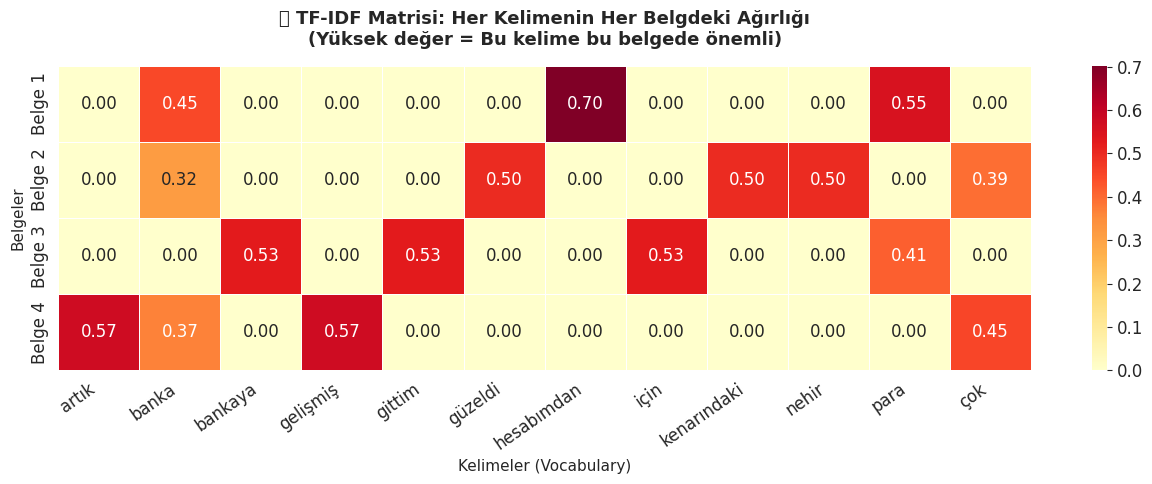

💡 Dikkat: "Banka" kelimesi tüm belgelerde var fakat hangi anlamda kullanıldığını
   TF-IDF bilmiyor. Bu yüzden Self-Attention'a ihtiyaç duyuldu!


In [4]:
# =============================================================================
# TF-IDF MATRİSİNİ GÖRSELLEŞTİR (Sklearn ile)
# 
# Sklearn'ın TfidfVectorizer'ı tüm belgeleri tek seferde matrise çevirir.
# Matrisin her satırı bir belgeyi, her sütunu bir kelimeyi temsil eder.
# =============================================================================

# Sklearn ile TF-IDF matrisi oluştur
vectorizer = TfidfVectorizer(
    max_features=12,   # En önemli 12 kelimeyi al
    sublinear_tf=True  # TF'nin logaritmasını al (büyük değerleri yumuşatmak için)
)

tfidf_matrix = vectorizer.fit_transform(belgeler).toarray()
kelimeler_listesi = vectorizer.get_feature_names_out()

# Isı haritası çiz
fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    tfidf_matrix,
    annot=True,
    fmt='.2f',
    xticklabels=kelimeler_listesi,
    yticklabels=[f'Belge {i+1}' for i in range(len(belgeler))],
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)

ax.set_title('📊 TF-IDF Matrisi: Her Kelimenin Her Belgdeki Ağırlığı\n'
             '(Yüksek değer = Bu kelime bu belgede önemli)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Kelimeler (Vocabulary)', fontsize=11)
ax.set_ylabel('Belgeler', fontsize=11)
plt.xticks(rotation=35, ha='right')

plt.tight_layout()
plt.savefig('tfidf_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Dikkat: "Banka" kelimesi tüm belgelerde var fakat hangi anlamda kullanıldığını')
print('   TF-IDF bilmiyor. Bu yüzden Self-Attention\'a ihtiyaç duyuldu!')

---
## 3. Self-Attention: Kelimeler Birbirini Dinliyor

Self-Attention, bir cümledeki **her kelimenin diğer tüm kelimelerle ne kadar ilişkili** olduğunu hesaplar.  

Örnek: `"Banka hesabımdan para çektim"` cümlesinde:
- **"banka"** → **"hesap"** ve **"para"** ile yüksek dikkat (finansal bağlam)
- **"banka"** → **"nehir"** ile düşük dikkat (nehir bu cümlede yok)

**Anahtar fark:** TF-IDF sadece kelime frekansına bakar.  
Self-Attention ise **kelimenin cümle içindeki tüm diğer kelimelerle ilişkisine** bakar. 🎯

### 👂 Self-Attention'ın Sezgisi

Self-Attention'ın temel fikri basit ama güçlü: **her kelime, cümledeki diğer tüm kelimelere "bakar" ve onlarla ne kadar ilişkili olduğuna karar verir.** Bu ilişki derecesi, sabit bir kural değil, veriden öğrenilen bir ağırlıktır.

Matematiksel formül:

`Attention(Q, K, V) = softmax(Q·Kᵀ / √d_k) · V`

Bu formülün sezgisi şu şekilde özetlenebilir:
1. Her kelimeyi bir **sorgu (Query)** olarak düşün: "Ben kiminle ilişkiliyim?"
2. Diğer tüm kelimeler birer **anahtar (Key)** sunar: "İşte benim ne olduğum."
3. Sorgu ile anahtarlar karşılaştırılır (iç çarpım), benzerlik skorları çıkar.
4. Bu skorlar **softmax** ile toplamı 1 olan olasılıklara çevrilir (dikkat ağırlıkları).
5. Bu ağırlıklarla, her kelimenin taşıdığı **değer (Value)** bilgisi ağırlıklı ortalanarak birleştirilir.

### 🆚 TF-IDF'ten Farkı

TF-IDF sabit, önceden hesaplanan bir skor üretirken, Self-Attention **her cümle için dinamik olarak** hesaplanır — aynı "banka" kelimesi, farklı cümlelerde farklı dikkat dağılımı üretir. Bu da bağlama duyarlı (context-aware) temsil demektir; modern dil modellerinin (BERT, GPT, Claude) temelini oluşturan da tam olarak budur.


In [5]:
# =============================================================================
# BASIC SELF-ATTENTION — Adım Adım Sıfırdan
# 
# Self-Attention formülü:
#   Attention(Q, K, V) = softmax(Q @ K.T / sqrt(d_k)) @ V
#
# Adımlar:
#   1. Her kelime için küçük bir embedding oluştur (temsil vektörü)
#   2. Q, K, V matrislerini rastgele başlat (normalde öğrenilir)
#   3. Q @ K.T ile "benzerlik skorları" hesapla
#   4. Softmax ile olasılığa çevir
#   5. V ile çarparak ağırlıklı çıktıyı bul
# =============================================================================

np.random.seed(42)  # Tekrar üretilebilirlik için

# ── Örnek cümle ──
cumle = ["Banka", "hesabımdan", "para", "çektim"]
n = len(cumle)     # Kelime sayısı = 4
d_model = 8        # Her kelimenin embedding boyutu (gerçekte 512 veya 768 olur)

# ── Adım 1: Kelime embeddingleri (basit örnek için rastgele oluşturduk) ──
# Gerçekte bu embeddingler GPT/BERT gibi modellerden gelir
X = np.random.randn(n, d_model)  # Şekil: (4 kelime, 8 boyut)

print('📐 Kelime Embedding Matrisi X:')
print(f'   Şekil: {X.shape}  →  ({n} kelime, {d_model} boyut)')
print(f'   Satırlar: {cumle}')
print()

# ── Adım 2: Q, K, V dönüşüm matrisleri (normalde eğitimle öğrenilir) ──
d_k = 4  # Query/Key boyutu (genellikle d_model / num_heads)

W_Q = np.random.randn(d_model, d_k)  # (8, 4) — Query projeksiyonu
W_K = np.random.randn(d_model, d_k)  # (8, 4) — Key projeksiyonu  
W_V = np.random.randn(d_model, d_k)  # (8, 4) — Value projeksiyonu

# ── Adım 3: Q, K, V hesapla ──
Q = X @ W_Q  # Sorgular: Bu kelime neye bakıyor?   Şekil: (4, 4)
K = X @ W_K  # Anahtarlar: Bu kelime neyi sunuyor?  Şekil: (4, 4)
V = X @ W_V  # Değerler: Gerçek bilgi içeriği       Şekil: (4, 4)

print('🔑 Q (Query) Matrisi — "Bu kelime ne soruyor?"')
print(f'   Şekil: {Q.shape}')
print()
print('🗝️  K (Key) Matrisi — "Bu kelime ne sunuyor?"')
print(f'   Şekil: {K.shape}')
print()
print('💎 V (Value) Matrisi — "Gerçek bilgi nerede?"')
print(f'   Şekil: {V.shape}')

📐 Kelime Embedding Matrisi X:
   Şekil: (4, 8)  →  (4 kelime, 8 boyut)
   Satırlar: ['Banka', 'hesabımdan', 'para', 'çektim']

🔑 Q (Query) Matrisi — "Bu kelime ne soruyor?"
   Şekil: (4, 4)

🗝️  K (Key) Matrisi — "Bu kelime ne sunuyor?"
   Şekil: (4, 4)

💎 V (Value) Matrisi — "Gerçek bilgi nerede?"
   Şekil: (4, 4)


📊 Ham Attention Skorları (Q @ K.T / sqrt(d_k)):
   Şekil: (4, 4)  →  Her kelime çiftinin benzerlik skoru


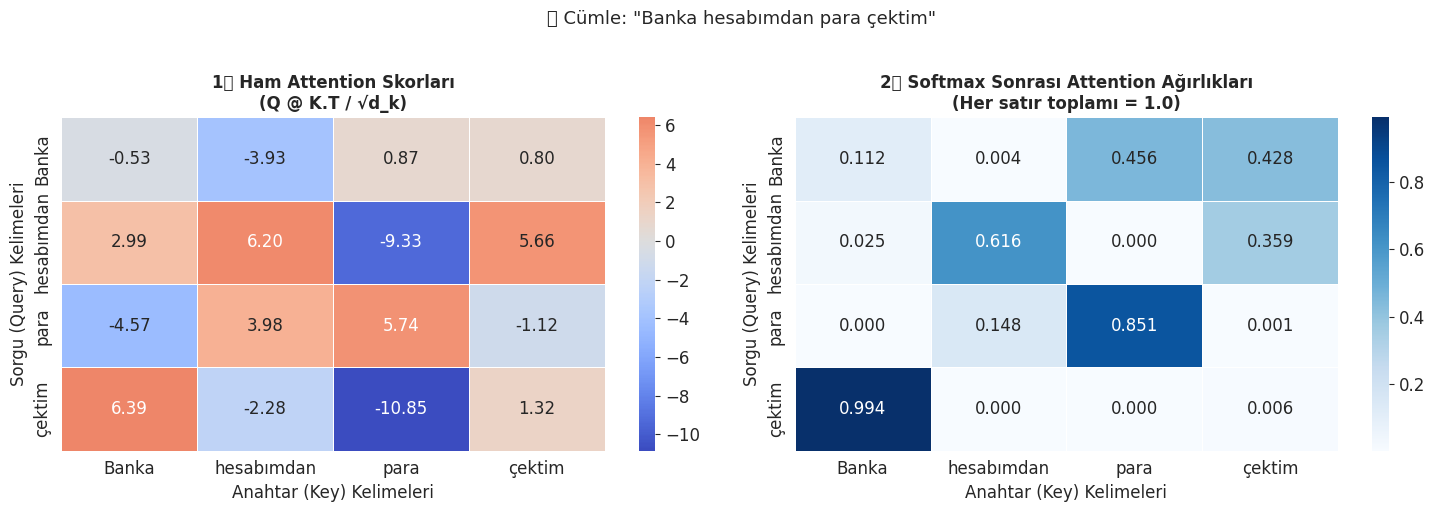

✅ Attention ağırlıkları hesaplandı!
   Her satır toplamı: [1. 1. 1. 1.]  (hepsi 1.0 olmalı)

🎯 Çıktı matrisi şekli: (4, 4)
   Her kelime artık diğer tüm kelimelerin bağlamını içeriyor!


In [6]:
# =============================================================================
# ATTENTION SKORLARINI HESAPLA VE GÖRSELLEŞTİR
# 
# Formül: scores = Q @ K.T / sqrt(d_k)
# 
# Neden sqrt(d_k)'ya bölüyoruz?
#   Nokta çarpımı, d_k büyüdükçe çok büyük değerler üretir.
#   Bu büyük değerler softmax'ı "doygunlaştırır" (saturate).
#   sqrt(d_k) ile bölerek gradyanların sağlıklı akmasını sağlarız.
# =============================================================================

# ── Adım 4: Ham Attention Skorları ──
# Q @ K.T: Her sorgunun her anahtarla olan iç çarpımı
# Yüksek skor = Bu iki kelime birbirine dikkat etmeli!
ham_skorlar = Q @ K.T / np.sqrt(d_k)  # Şekil: (4, 4)

print('📊 Ham Attention Skorları (Q @ K.T / sqrt(d_k)):')
print(f'   Şekil: {ham_skorlar.shape}  →  Her kelime çiftinin benzerlik skoru')

# ── Adım 5: Softmax ile olasılığa çevir ──
def softmax(x, axis=-1):
    """Sayısal kararlılık için max çıkarımı yapılmış softmax"""
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

attention_weights = softmax(ham_skorlar)  # Her satır toplamı = 1.0

# ── Adım 6: Ağırlıklı çıktı ──
output = attention_weights @ V  # Şekil: (4, 4)

# ── Görselleştirme ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol: Ham skorlar
sns.heatmap(
    ham_skorlar, annot=True, fmt='.2f',
    xticklabels=cumle, yticklabels=cumle,
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('1️⃣ Ham Attention Skorları\n(Q @ K.T / √d_k)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Anahtar (Key) Kelimeleri')
axes[0].set_ylabel('Sorgu (Query) Kelimeleri')

# Sağ: Softmax sonrası (gerçek ağırlıklar)
sns.heatmap(
    attention_weights, annot=True, fmt='.3f',
    xticklabels=cumle, yticklabels=cumle,
    cmap='Blues',
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('2️⃣ Softmax Sonrası Attention Ağırlıkları\n(Her satır toplamı = 1.0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anahtar (Key) Kelimeleri')
axes[1].set_ylabel('Sorgu (Query) Kelimeleri')

plt.suptitle(f'📌 Cümle: "{" ".join(cumle)}"', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Attention ağırlıkları hesaplandı!')
print(f'   Her satır toplamı: {attention_weights.sum(axis=1)}  (hepsi 1.0 olmalı)')
print(f'\n🎯 Çıktı matrisi şekli: {output.shape}')
print('   Her kelime artık diğer tüm kelimelerin bağlamını içeriyor!')

---
## 4. Q, K, V Matrisleri — Soru, Anahtar, Değer

Bunu bir **kütüphane arama sistemi** gibi düşünebilirsin:

| Matris | Türkçe | Kütüphane Analojisi |
|--------|--------|---------------------|
| **Q** (Query) | Sorgu | Okuyucunun aradığı konu |
| **K** (Key) | Anahtar | Kitapların katalog kartları |
| **V** (Value) | Değer | Kitapların gerçek içeriği |

Okuyucu (Q) katalog kartlarına (K) bakar, en uygun kitabı bulur, o kitabın içeriğini (V) okur. 📚

### 🔑 Q, K, V Nasıl Elde Edilir?

Her kelimenin embedding vektörü (x), üç farklı öğrenilebilir ağırlık matrisiyle (Wq, Wk, Wv) çarpılarak üç farklı temsile dönüştürülür:

`Q = x · Wq`,  `K = x · Wk`,  `V = x · Wv`

Bu üç matris, eğitim sırasında **backpropagation** ile öğrenilir — yani model, hangi kelimelerin birbirine dikkat etmesi gerektiğini veriden kendisi keşfeder, kimse elle kural yazmaz.

### 📚 Neden 3 Ayrı Matris?

Tek bir vektör yerine üç ayrı rol tanımlamak, modele esneklik kazandırır: bir kelime "ne arıyorum" (Query) açısından bir şekilde, "ben neyim" (Key) açısından başka bir şekilde, "taşıdığım bilgi" (Value) açısından yine başka bir şekilde temsil edilebilir. Bu ayrım, ilişkilerin daha zengin öğrenilmesini sağlar.

### ➗ Neden √d_k'ya Bölüyoruz?

Q·Kᵀ çarpımı, boyut (d_k) büyüdükçe değerleri de büyütür. Çok büyük değerler softmax fonksiyonunu "doygunlaştırır" — yani softmax çıktısı neredeyse 0 ve 1'lerden oluşan aşırı keskin bir dağılıma döner, bu da gradyanların sağlıklı akmasını engeller. √d_k'ya bölmek, skorları makul bir aralıkta tutarak eğitimi kararlı hale getirir.


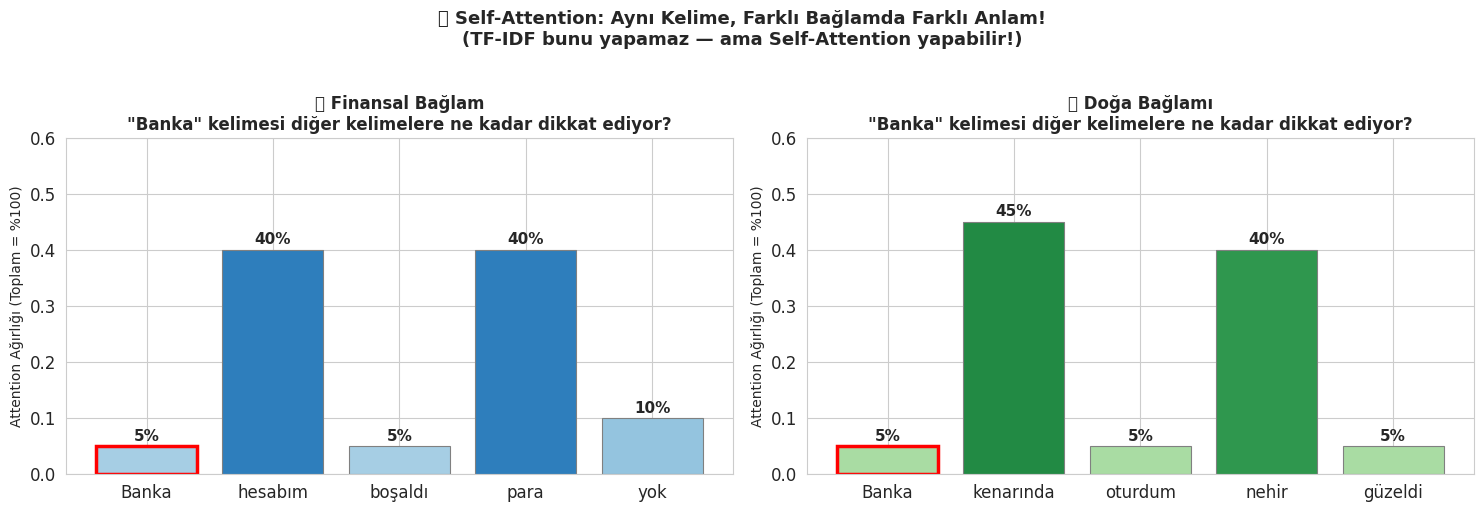

✨ İşte bu yüzden Self-Attention TF-IDF'ten çok daha güçlü!
   "Banka" kelimesi bağlama göre farklı kelimelere dikkat ediyor.


In [7]:
# =============================================================================
# Q, K, V SEZGISEL GÖRSEL AÇIKLAMA
# 
# Banka bağlamında iki farklı cümle için dikkat dağılımını simüle ediyoruz.
# Gerçek transformer ağırlıkları yerine "bağlam temelli" skorlar kullanıyoruz.
# =============================================================================

# İki farklı bağlamdaki "banka" cümleleri
cumle1 = ["Banka", "hesabım", "boşaldı", "para", "yok"]
cumle2 = ["Banka", "kenarında", "oturdum", "nehir", "güzeldi"]

# Self-Attention bağlamında dikkat ağırlıklarını simüle et
# (Finansal bağlam: "banka" → "hesabım", "para" ile yüksek dikkat)
# (Doğa bağlamı: "banka" → "kenarında", "nehir" ile yüksek dikkat)
dikkat_finansal = np.array([0.05, 0.40, 0.05, 0.40, 0.10])  # Banka→diğerleri
dikkat_doga    = np.array([0.05, 0.45, 0.05, 0.40, 0.05])   # Banka→diğerleri

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, cumle, dikkat, baslik, renk in zip(
    axes,
    [cumle1, cumle2],
    [dikkat_finansal, dikkat_doga],
    ['💰 Finansal Bağlam', '🌿 Doğa Bağlamı'],
    ['Blues', 'Greens']
):
    bars = ax.bar(cumle, dikkat, color=plt.cm.get_cmap(renk)(dikkat + 0.3),
                  edgecolor='gray', linewidth=0.8)
    
    # Değerleri göster
    for bar, d in zip(bars, dikkat):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{d:.0%}', ha='center', fontsize=11, fontweight='bold')
    
    ax.set_title(f'{baslik}\n"Banka" kelimesi diğer kelimelere ne kadar dikkat ediyor?',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Attention Ağırlığı (Toplam = %100)', fontsize=10)
    ax.set_ylim(0, 0.6)
    
    # İlk bar'ı ("Banka") vurgula — bu kelime kendine bakıyor
    bars[0].set_edgecolor('red')
    bars[0].set_linewidth(2.5)

plt.suptitle('🎯 Self-Attention: Aynı Kelime, Farklı Bağlamda Farklı Anlam!\n'
             '(TF-IDF bunu yapamaz — ama Self-Attention yapabilir!)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('qkv_baglam.png', dpi=150, bbox_inches='tight')
plt.show()

print('✨ İşte bu yüzden Self-Attention TF-IDF\'ten çok daha güçlü!')
print('   "Banka" kelimesi bağlama göre farklı kelimelere dikkat ediyor.')

---
## 5. Multi-Head Attention — Birden Fazla Bakış Açısı

Tek bir attention head yeterli değil! Neden?  
Çünkü bir cümledeki ilişkiler **çok boyutlu**: sözdizimsel, anlamsal, dilbilgisel...

**Multi-Head Attention**, aynı cümleye **birden fazla farklı Q/K/V seti** ile bakarak  
her head'in farklı bir ilişki kalıbını öğrenmesine izin verir.

```
Input → [Head 1: Sözdizim]  ─┐
        [Head 2: Anlam    ]  ─┤ → Concat → Linear → Output  
        [Head 3: Referans ]  ─┘
```

### 🎭 Tek Bakış Açısı Neden Yetmez?

Bir cümledeki kelimeler arasında aynı anda birden fazla türde ilişki bulunabilir: sözdizimsel (özne-yüklem), anlamsal (eş anlamlılık/konu bütünlüğü), referansal (zamir neyi işaret ediyor) gibi. Tek bir Q/K/V seti, bu farklı ilişki türlerinin hepsini aynı anda iyi yakalayamaz — ortalama bir uzlaşmaya zorlanır.

### 🧩 Çözüm: Paralel "Head"ler

Multi-Head Attention, `d_model` boyutunu `num_heads` parçaya böler ve her parça için **ayrı** Q, K, V matrisleriyle **bağımsız** bir attention hesabı yapar. Her head, kendi küçük boyutunda farklı bir ilişki kalıbı öğrenmeye "özgürleşir" — biri sözdizimine, biri anlam benzerliğine odaklanabilir.

Son adımda tüm head'lerin çıktıları **birleştirilir (concatenate)** ve bir doğrusal katmandan (linear layer) geçirilerek tekrar `d_model` boyutuna getirilir. Bu sayede model, cümleyi aynı anda birden çok "gözlükle" incelemiş olur.


In [8]:
# =============================================================================
# MULTI-HEAD ATTENTION — Sıfırdan Implementasyon
# 
# Adımlar:
#   1. Toplam d_model'i num_heads'e böl → her head d_k boyutunda çalışır
#   2. Her head için ayrı Q, K, V hesapla
#   3. Her head kendi attention'ını hesaplar
#   4. Tüm head'lerin çıktılarını birleştir (concatenate)
#   5. Son bir Linear katmanıyla boyutu düzenle
# =============================================================================

class MultiHeadAttention:
    def __init__(self, d_model=16, num_heads=2):
        """
        d_model: Toplam embedding boyutu
        num_heads: Kaç farklı 'bakış açısı' kullanacağız?
        d_k: Her head'in boyutu = d_model / num_heads
        """
        assert d_model % num_heads == 0, "d_model, num_heads'e tam bölünmeli!"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Her head'in boyutu
        
        # Her head için ayrı W_Q, W_K, W_V matrisleri (normalde öğrenilir)
        np.random.seed(42)
        self.W_Q = [np.random.randn(d_model, self.d_k) * 0.1 for _ in range(num_heads)]
        self.W_K = [np.random.randn(d_model, self.d_k) * 0.1 for _ in range(num_heads)]
        self.W_V = [np.random.randn(d_model, self.d_k) * 0.1 for _ in range(num_heads)]
        
        # Birleştirme sonrası boyutu düzenleyen matris
        self.W_O = np.random.randn(d_model, d_model) * 0.1
    
    def scaled_dot_product_attention(self, Q, K, V):
        """Tek bir head için Scaled Dot-Product Attention"""
        scores = Q @ K.T / np.sqrt(self.d_k)
        weights = softmax(scores)  # Önceki softmax fonksiyonunu kullan
        output = weights @ V
        return output, weights
    
    def forward(self, X):
        """Multi-Head Attention ileri geçişi"""
        tum_head_ciktilari = []
        tum_head_agirliklari = []
        
        for h in range(self.num_heads):
            # Her head farklı matrislerle Q, K, V üretir
            Q_h = X @ self.W_Q[h]
            K_h = X @ self.W_K[h]
            V_h = X @ self.W_V[h]
            
            # Bu head'in attention'ını hesapla
            cikti_h, agirlik_h = self.scaled_dot_product_attention(Q_h, K_h, V_h)
            
            tum_head_ciktilari.append(cikti_h)
            tum_head_agirliklari.append(agirlik_h)
            
            print(f'  Head {h+1}: Attention matrisi şekli = {agirlik_h.shape}')
        
        # Tüm head'lerin çıktılarını birleştir: (n, num_heads * d_k) = (n, d_model)
        concat = np.concatenate(tum_head_ciktilari, axis=-1)
        
        # Son linear projeksiyon
        final_output = concat @ self.W_O
        
        return final_output, tum_head_agirliklari


# ── Test ──
np.random.seed(42)
n_kelime, d_model, num_heads = 4, 16, 2
X_test = np.random.randn(n_kelime, d_model)

mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads)

print(f'Multi-Head Attention ({num_heads} head, d_model={d_model}, d_k={d_model//num_heads})')
print(f'Giriş şekli: {X_test.shape}  →  ({n_kelime} kelime, {d_model} boyut)')
print()
print('Her head\'in attention matrisi:')
final_output, agirliklar = mha.forward(X_test)
print()
print(f'Birleştirme sonrası çıktı şekli: {final_output.shape}')
print(f'(Giriş ve çıkış boyutu aynı: {d_model} — transformer blokları bu şekilde zincirlenebilir!)')

Multi-Head Attention (2 head, d_model=16, d_k=8)
Giriş şekli: (4, 16)  →  (4 kelime, 16 boyut)

Her head'in attention matrisi:
  Head 1: Attention matrisi şekli = (4, 4)
  Head 2: Attention matrisi şekli = (4, 4)

Birleştirme sonrası çıktı şekli: (4, 16)
(Giriş ve çıkış boyutu aynı: 16 — transformer blokları bu şekilde zincirlenebilir!)


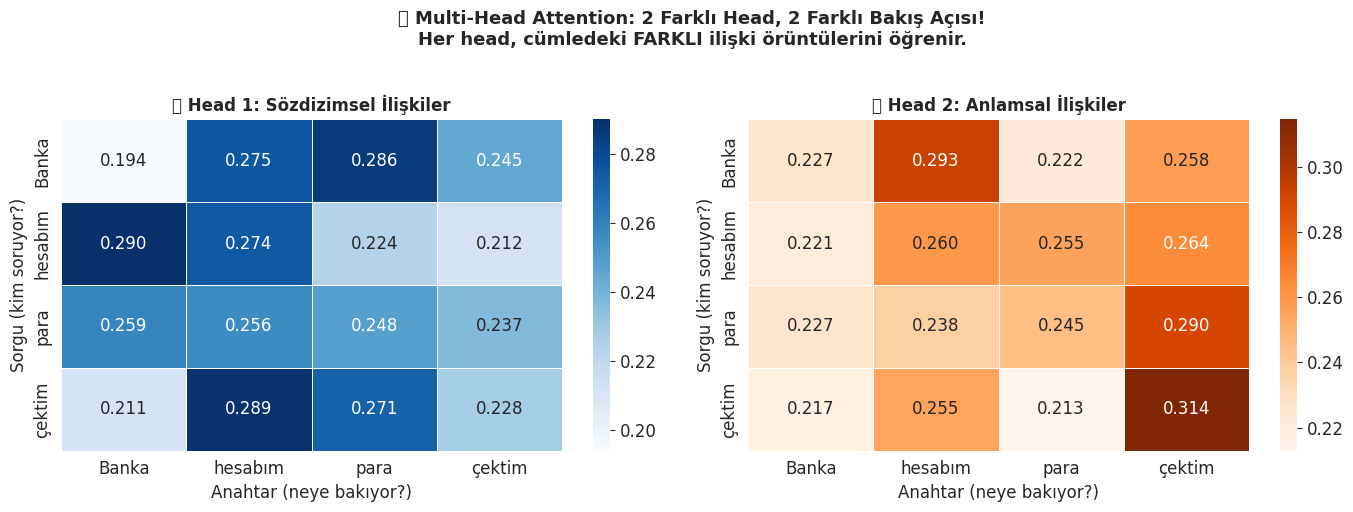

💡 Gerçek modellerde 8, 12 veya 16 head kullanılır!
   GPT-2 Small: 12 head | GPT-3: 96 head | BERT-Base: 12 head


In [9]:
# =============================================================================
# MULTI-HEAD ATTENTION GÖRSELLEŞTİRME
# 
# Her head farklı bir ilişki örüntüsü öğrenir.
# Bu grafikte 2 head'in farklı dikkat dağılımlarını karşılaştırıyoruz.
# =============================================================================

cumle_kelimeleri = ["Banka", "hesabım", "para", "çektim"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

head_isimleri = ['Head 1: Sözdizimsel İlişkiler', 'Head 2: Anlamsal İlişkiler']
renkler = ['Blues', 'Oranges']

for idx, (ax, agirlik, isim, renk) in enumerate(zip(axes, agirliklar, head_isimleri, renkler)):
    sns.heatmap(
        agirlik,
        annot=True, fmt='.3f',
        xticklabels=cumle_kelimeleri,
        yticklabels=cumle_kelimeleri,
        cmap=renk,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'🔍 {isim}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Anahtar (neye bakıyor?)')
    ax.set_ylabel('Sorgu (kim soruyor?)')

plt.suptitle(
    '🧠 Multi-Head Attention: 2 Farklı Head, 2 Farklı Bakış Açısı!\n'
    'Her head, cümledeki FARKLI ilişki örüntülerini öğrenir.',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('multi_head_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Gerçek modellerde 8, 12 veya 16 head kullanılır!')
print('   GPT-2 Small: 12 head | GPT-3: 96 head | BERT-Base: 12 head')

---
## 6. TF-IDF vs Self-Attention — Kapsamlı Karşılaştırma

### ⚖️ İki Yaklaşımın Güçlü/Zayıf Yönleri

| Kriter | TF-IDF | Self-Attention |
|---|---|---|
| Bağlam anlama | ❌ Yok — kelime her yerde aynı temsil edilir | ✅ Var — aynı kelime bağlama göre farklı temsil edilir |
| Kelime sırası/pozisyon | ❌ Yok (Bag of Words mantığı) | ✅ Positional encoding ile eklenir |
| Kelimeler arası ilişki | ❌ Yakalanmaz | ✅ Doğrudan modellenir (Q·Kᵀ) |
| Hesaplama maliyeti | ✅ Çok düşük, doğrusal | ❌ O(n²) — cümle uzunluğunun karesiyle artar |
| Paralelleştirme | ✅ Kolay | ✅ RNN'e göre çok daha paralel |

Self-Attention'ın en büyük bedeli, hesaplama karmaşıklığının cümle uzunluğunun **karesiyle** (O(n²)) büyümesidir — bu yüzden çok uzun metinlerde bellek/hız sorunu oluşabilir (bu, günümüzde "uzun bağlam" araştırmalarının ana motivasyonlarından biridir).


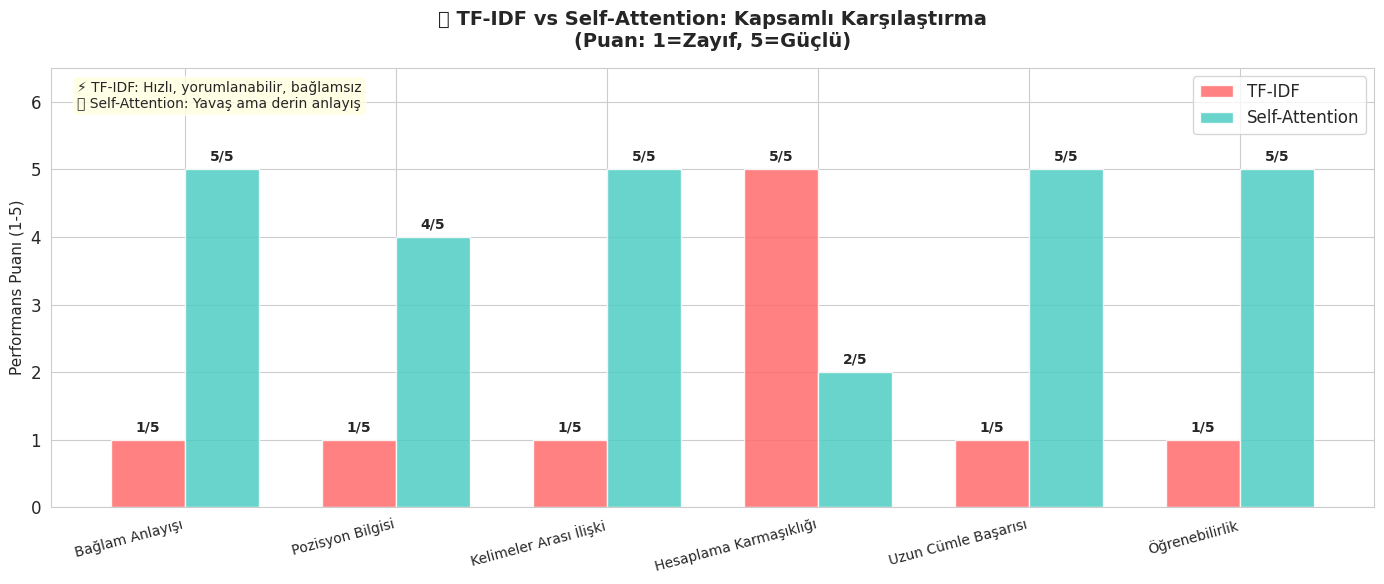


Kriter                             TF-IDF      Self-Attention 
Bağlam Anlayışı                       ❌               ✅       
Pozisyon Bilgisi                      ❌               ✅       
Kelimeler Arası İlişki                ❌               ✅       
Hesaplama Karmaşıklığı                ✅              ⚠️       
Uzun Cümle Başarısı                   ❌               ✅       
Öğrenebilirlik                        ❌               ✅       


In [10]:
# =============================================================================
# TF-IDF vs SELF-ATTENTION — Yan Yana Karşılaştırma
# 
# Bu bölümde iki yöntemin temel farklarını hem tablo hem grafik olarak
# görselleştiriyoruz. Asıl kod değil, eğitici bir görselleştirme.
# =============================================================================

# Karşılaştırma kriterleri
kriterler = [
    'Bağlam Anlayışı',
    'Pozisyon Bilgisi',
    'Kelimeler Arası İlişki',
    'Hesaplama Karmaşıklığı',
    'Uzun Cümle Başarısı',
    'Öğrenebilirlik'
]

# Puan: 1 (zayıf) → 5 (güçlü)
tfidf_puanlari     = [1, 1, 1, 5, 1, 1]  # TF-IDF basit ama sınırlı
attention_puanlari = [5, 4, 5, 2, 5, 5]  # Self-Attention güçlü ama hesap yoğun

x = np.arange(len(kriterler))
genislik = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - genislik/2, tfidf_puanlari, genislik,
               label='TF-IDF', color='#FF6B6B', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + genislik/2, attention_puanlari, genislik,
               label='Self-Attention', color='#4ECDC4', alpha=0.85, edgecolor='white')

# Değerleri göster
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.08,
                f'{int(h)}/5', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('📊 TF-IDF vs Self-Attention: Kapsamlı Karşılaştırma\n(Puan: 1=Zayıf, 5=Güçlü)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(kriterler, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Performans Puanı (1-5)', fontsize=11)
ax.set_ylim(0, 6.5)
ax.legend(fontsize=12, loc='upper right')

# Açıklama kutusu
ax.text(0.02, 0.97,
    '⚡ TF-IDF: Hızlı, yorumlanabilir, bağlamsız\n'
    '🧠 Self-Attention: Yavaş ama derin anlayış',
    transform=ax.transAxes, fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()
plt.savefig('tfidf_vs_attention.png', dpi=150, bbox_inches='tight')
plt.show()

# Özet tablosu yazdır
print('\n' + '='*65)
print(f'{"Kriter":<30} {"TF-IDF":^15} {"Self-Attention":^15}')
print('='*65)
emojiler_tfidf     = ['❌', '❌', '❌', '✅', '❌', '❌']
emojiler_attention = ['✅', '✅', '✅', '⚠️ ', '✅', '✅']
for k, t, a in zip(kriterler, emojiler_tfidf, emojiler_attention):
    print(f'{k:<30} {t:^15} {a:^15}')
print('='*65)

---
## 7. Tam Transformer Encoder Bloğu

Gerçek bir Transformer bloku şu bileşenlerden oluşur:

```
Input Embedding
       ↓
+ Positional Encoding   (kelime pozisyonunu kodlar)
       ↓
┌─ Multi-Head Attention ─┐
│  + Residual Connection │  (Add & Norm)
│  + Layer Normalization │
└────────────────────────┘
       ↓
┌─ Feed-Forward Network ─┐
│  + Residual Connection │  (Add & Norm)
│  + Layer Normalization │
└────────────────────────┘
       ↓
   Output
```

### 🏗️ Bir Transformer Bloğunun Bileşenleri

Gerçek bir Transformer encoder bloğu, sadece attention'dan ibaret değildir; birkaç kritik bileşen bir araya gelir:

1. **Positional Encoding:** Attention, kelime sırasını doğal olarak bilmez (Q·Kᵀ işlemi sıraya duyarsızdır). Bu yüzden her kelimenin embedding'ine, sinüs/kosinüs fonksiyonlarıyla üretilen bir "pozisyon parmak izi" eklenir. Farklı frekanslardaki sinüs/kosinüs dalgaları, her pozisyona benzersiz bir desen kazandırır.

2. **Multi-Head Attention:** Kelimeler arası ilişkileri farklı açılardan hesaplar (yukarıda anlatıldı).

3. **Residual Connection (Artık Bağlantı):** Bir katmanın girdisi, çıktısına doğrudan eklenir (`output = layer(x) + x`). Bu, derin ağlarda gradyanların kaybolmadan geriye akmasını sağlar — çok katmanlı Transformer'ların eğitilebilir olmasının kritik sebeplerinden biridir.

4. **Layer Normalization:** Her katmanın çıktısını normalleştirerek (ortalama 0, varyans 1'e yakın) eğitimi daha kararlı ve hızlı hale getirir.

5. **Feed-Forward Network (FFN):** Attention çıktısını, genelde `d_model → 4×d_model → d_model` boyutlarında iki katmanlı, non-lineer bir ağdan geçirir. Attention kelimeler arası ilişkiyi kurarken, FFN her pozisyonu ayrı ayrı daha da işler.

Bu beş bileşen bir araya gelip N kez üst üste yığıldığında (GPT, BERT gibi modellerde onlarca kat), ortaya bugünün büyük dil modellerinin omurgası çıkar.


In [11]:
# =============================================================================
# TAM TRANSFORMER ENCODER BLOĞU
# 
# Bu implementasyon şu bileşenleri içerir:
#   1. Positional Encoding: Kelime pozisyonunu sinüs/kosinüs ile kodlar
#   2. Multi-Head Attention: Önceki MultiHeadAttention sınıfını kullanır
#   3. Residual Connection: Girişi çıkışa ekler (gradyan akışı için kritik)
#   4. Layer Normalization: Her katmanı normalleştirir (eğitimi kararlı kılar)
#   5. Feed-Forward Network: 2 katlı tam bağlı ağ (d_model → 4*d_model → d_model)
# =============================================================================

class TransformerEncoderBlock:
    def __init__(self, d_model=16, num_heads=2, d_ff=64):
        """
        d_model: Embedding boyutu
        num_heads: Multi-head attention head sayısı  
        d_ff: Feed-forward katmanının gizli boyutu (genelde 4 * d_model)
        """
        self.d_model = d_model
        self.mha = MultiHeadAttention(d_model, num_heads)
        
        # Feed-Forward Network ağırlıkları
        np.random.seed(0)
        self.W1 = np.random.randn(d_model, d_ff) * 0.1   # Genişleme: d_model → d_ff
        self.b1 = np.zeros(d_ff)
        self.W2 = np.random.randn(d_ff, d_model) * 0.1   # Daralma: d_ff → d_model
        self.b2 = np.zeros(d_model)
    
    def layer_norm(self, X, eps=1e-6):
        """
        Layer Normalization: Her token'ı kendi istatistikleriyle normalleştirir
        Formül: (X - mean) / sqrt(variance + epsilon)
        eps: Sıfıra bölmeyi önlemek için küçük bir sayı
        """
        mean = X.mean(axis=-1, keepdims=True)
        std  = X.std(axis=-1, keepdims=True)
        return (X - mean) / (std + eps)
    
    def relu(self, x):
        """ReLU aktivasyon: negatif değerleri sıfırlar"""
        return np.maximum(0, x)
    
    def feed_forward(self, X):
        """
        Position-wise Feed-Forward Network:
        Her kelime için aynı iki katmanlı ağ uygulanır.
        FFN(x) = ReLU(x @ W1 + b1) @ W2 + b2
        """
        gizli = self.relu(X @ self.W1 + self.b1)  # Genişlet: d_model → d_ff
        cikti = gizli @ self.W2 + self.b2          # Daralt: d_ff → d_model
        return cikti
    
    def positional_encoding(self, n, d):
        """
        Pozisyonel Kodlama: Transformer pozisyon bilmez, bunu elle ekliyoruz.
        Çift indeksler için sinus, tek indeksler için kosinüs kullanılır.
        
        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
        """
        PE = np.zeros((n, d))
        for pos in range(n):
            for i in range(0, d, 2):
                frekans = 10000 ** (2*i / d)
                PE[pos, i]   = np.sin(pos / frekans)
                if i+1 < d:
                    PE[pos, i+1] = np.cos(pos / frekans)
        return PE
    
    def forward(self, X):
        """
        Tam Encoder Bloğu İleri Geçişi:
        1. Positional Encoding ekle
        2. Multi-Head Attention + Residual + LayerNorm
        3. Feed-Forward + Residual + LayerNorm
        """
        n, d = X.shape
        
        # Adım 1: Pozisyonel kodlamayı ekle
        PE = self.positional_encoding(n, d)
        X = X + PE  # Embeddings + Positional Encoding
        
        # Adım 2: Multi-Head Attention + Add & Norm
        attention_cikti, _ = self.mha.forward(X)
        X = self.layer_norm(X + attention_cikti)  # Residual connection!
        
        # Adım 3: Feed-Forward + Add & Norm
        ff_cikti = self.feed_forward(X)
        X = self.layer_norm(X + ff_cikti)  # Residual connection!
        
        return X


# ── Test ──
np.random.seed(42)

n_kelime = 4
d_model  = 16
num_heads = 2
d_ff = 64  # 4 * d_model

# Rastgele giriş: 4 kelime, her biri 16 boyutlu embedding
X_giris = np.random.randn(n_kelime, d_model)

encoder = TransformerEncoderBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff)
X_cikis = encoder.forward(X_giris)

print('🏗️  Transformer Encoder Bloğu Testi')
print(f'   Giriş şekli : {X_giris.shape}  →  ({n_kelime} kelime, {d_model} boyut)')
print(f'   Çıkış şekli : {X_cikis.shape}  →  ({n_kelime} kelime, {d_model} boyut)')
print()
print(f'   Giriş istatistikleri  — Ortalama: {X_giris.mean():.3f}, Std: {X_giris.std():.3f}')
print(f'   Çıkış istatistikleri  — Ortalama: {X_cikis.mean():.3f}, Std: {X_cikis.std():.3f}')
print()
print('✅ Boyut korunuyor: Giriş ve çıkış aynı şekilde!')
print('   Bu sayede N adet Encoder bloğu üst üste zincirlenebilir.')

  Head 1: Attention matrisi şekli = (4, 4)
  Head 2: Attention matrisi şekli = (4, 4)
🏗️  Transformer Encoder Bloğu Testi
   Giriş şekli : (4, 16)  →  (4 kelime, 16 boyut)
   Çıkış şekli : (4, 16)  →  (4 kelime, 16 boyut)

   Giriş istatistikleri  — Ortalama: -0.191, Std: 0.890
   Çıkış istatistikleri  — Ortalama: 0.000, Std: 1.000

✅ Boyut korunuyor: Giriş ve çıkış aynı şekilde!
   Bu sayede N adet Encoder bloğu üst üste zincirlenebilir.


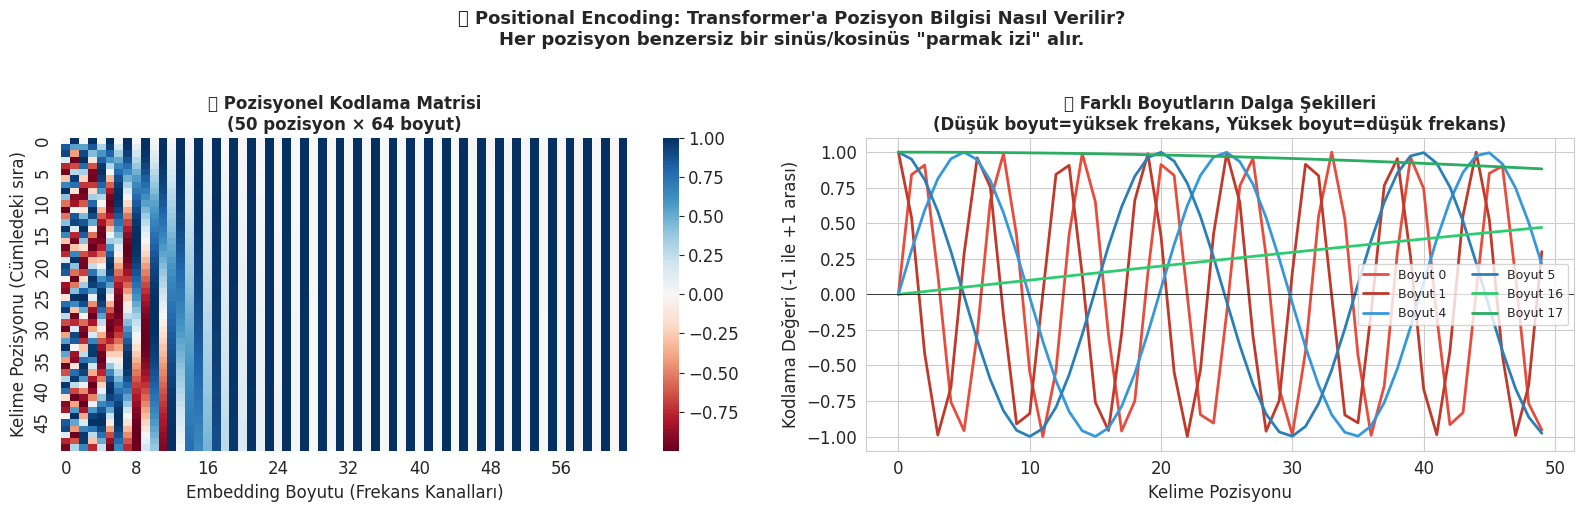

💡 Önemli: Transformer kelime sırasını bilmez!
   Positional Encoding bu bilgiyi embedding'e "ekler".
   Sinüs/Kosinüs seçilmesinin nedeni: Her pozisyon için benzersiz,
   öğrenilmesi kolay ve eğitimde görülenden uzun cümleler için de genelleşebilir!


In [12]:
# =============================================================================
# POZİSYONEL KODLAMA GÖRSELLEŞTİRME
# 
# Positional Encoding'in neden sinüs/kosinüs kullandığını görüyoruz.
# Her boyut farklı frekansta dalgalanır — bu sayede her pozisyon
# benzersiz bir "parmak izi" alır.
# =============================================================================

def pozisyonel_kodlama_gorsellestir(max_pos=50, d_model=64):
    PE = np.zeros((max_pos, d_model))
    for pos in range(max_pos):
        for i in range(0, d_model, 2):
            frekans = 10000 ** (2*i / d_model)
            PE[pos, i]   = np.sin(pos / frekans)
            if i+1 < d_model:
                PE[pos, i+1] = np.cos(pos / frekans)
    return PE

PE = pozisyonel_kodlama_gorsellestir(max_pos=50, d_model=64)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sol: Isı haritası (tüm PE matrisi)
sns.heatmap(PE, cmap='RdBu', center=0, ax=axes[0],
            xticklabels=8, yticklabels=5)
axes[0].set_title('🌊 Pozisyonel Kodlama Matrisi\n(50 pozisyon × 64 boyut)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Embedding Boyutu (Frekans Kanalları)')
axes[0].set_ylabel('Kelime Pozisyonu (Cümledeki sıra)')

# Sağ: İlk birkaç boyutun dalga şekli
for i, (boyut, renk) in enumerate(zip([0, 1, 4, 5, 16, 17], 
                                      ['#E74C3C','#C0392B','#3498DB','#2980B9','#2ECC71','#27AE60'])):
    axes[1].plot(PE[:, boyut], label=f'Boyut {boyut}', color=renk, linewidth=2)

axes[1].set_title('📡 Farklı Boyutların Dalga Şekilleri\n(Düşük boyut=yüksek frekans, Yüksek boyut=düşük frekans)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kelime Pozisyonu')
axes[1].set_ylabel('Kodlama Değeri (-1 ile +1 arası)')
axes[1].legend(fontsize=9, ncol=2)
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('📍 Positional Encoding: Transformer\'a Pozisyon Bilgisi Nasıl Verilir?\n'
             'Her pozisyon benzersiz bir sinüs/kosinüs "parmak izi" alır.',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Önemli: Transformer kelime sırasını bilmez!')
print('   Positional Encoding bu bilgiyi embedding\'e "ekler".')
print('   Sinüs/Kosinüs seçilmesinin nedeni: Her pozisyon için benzersiz,')
print('   öğrenilmesi kolay ve eğitimde görülenden uzun cümleler için de genelleşebilir!')

---
## 📋 Özet: TF-IDF'ten Transformer'a Evrim

| Yöntem | Temel Fikir | Zayıf Yanı |
|--------|-------------|------------|
| **Bag of Words** | Kelime sayıları | Sıra yok, bağlam yok |
| **TF-IDF** | Kelime önemi (nadirlik × frekans) | Bağlam yok |
| **RNN** | Soldan sağa gizli durum | Uzun cümlelerde hafıza kaybı |
| **LSTM/GRU** | Kapılı hafıza hücreleri | Yavaş, paralel değil |
| **Self-Attention** | Her kelime her kelimeye bakabilir | O(n²) hesaplama |
| **Transformer** | Multi-head attention + FF + positional enc. | Büyük veri/hesap gerektirir |

---

### 🚀 Sonraki Adımlar
- **PyTorch ile Gerçek Transformer**: `nn.TransformerEncoderLayer`
- **Hugging Face BERT**: Pre-trained attention ağırlıklarını görselleştirme
- **Attention is All You Need** (Vaswani et al., 2017): Orijinal makale
- **Flash Attention**: O(n²)'yi O(n)'e indiren optimizasyon

### 🧭 Büyük Resim

Bu notebook boyunca izlediğimiz yolculuk aslında NLP'nin (Doğal Dil İşleme) kısa tarihidir:

- **Bag of Words / TF-IDF** kelimeleri sayarak, istatistiksel olarak önemliyi yakalamaya çalıştı — ama sıra ve bağlam kördü.
- **RNN/LSTM/GRU** sırayı işleyerek bağlamı bir dereceye kadar yakaladı — ama uzun mesafede hafıza kaybetti ve paralelleştirilemedi.
- **Self-Attention** her kelimenin her kelimeye doğrudan bakabilmesini sağlayarak hem bağlamı hem uzun-mesafe ilişkileri çözdü, üstelik paralel hesaplanabilir.
- **Transformer**, bu attention mekanizmasını positional encoding, residual bağlantılar ve feed-forward katmanlarıyla birleştirerek bugünün GPT, BERT, Claude gibi modellerinin mimari temelini oluşturdu.

Bu ilerlemenin bedeli hesaplama maliyetidir (O(n²)), ve günümüzdeki birçok araştırma (sparse attention, linear attention, uzun bağlam mimarileri) tam olarak bu maliyeti azaltmaya odaklanır.


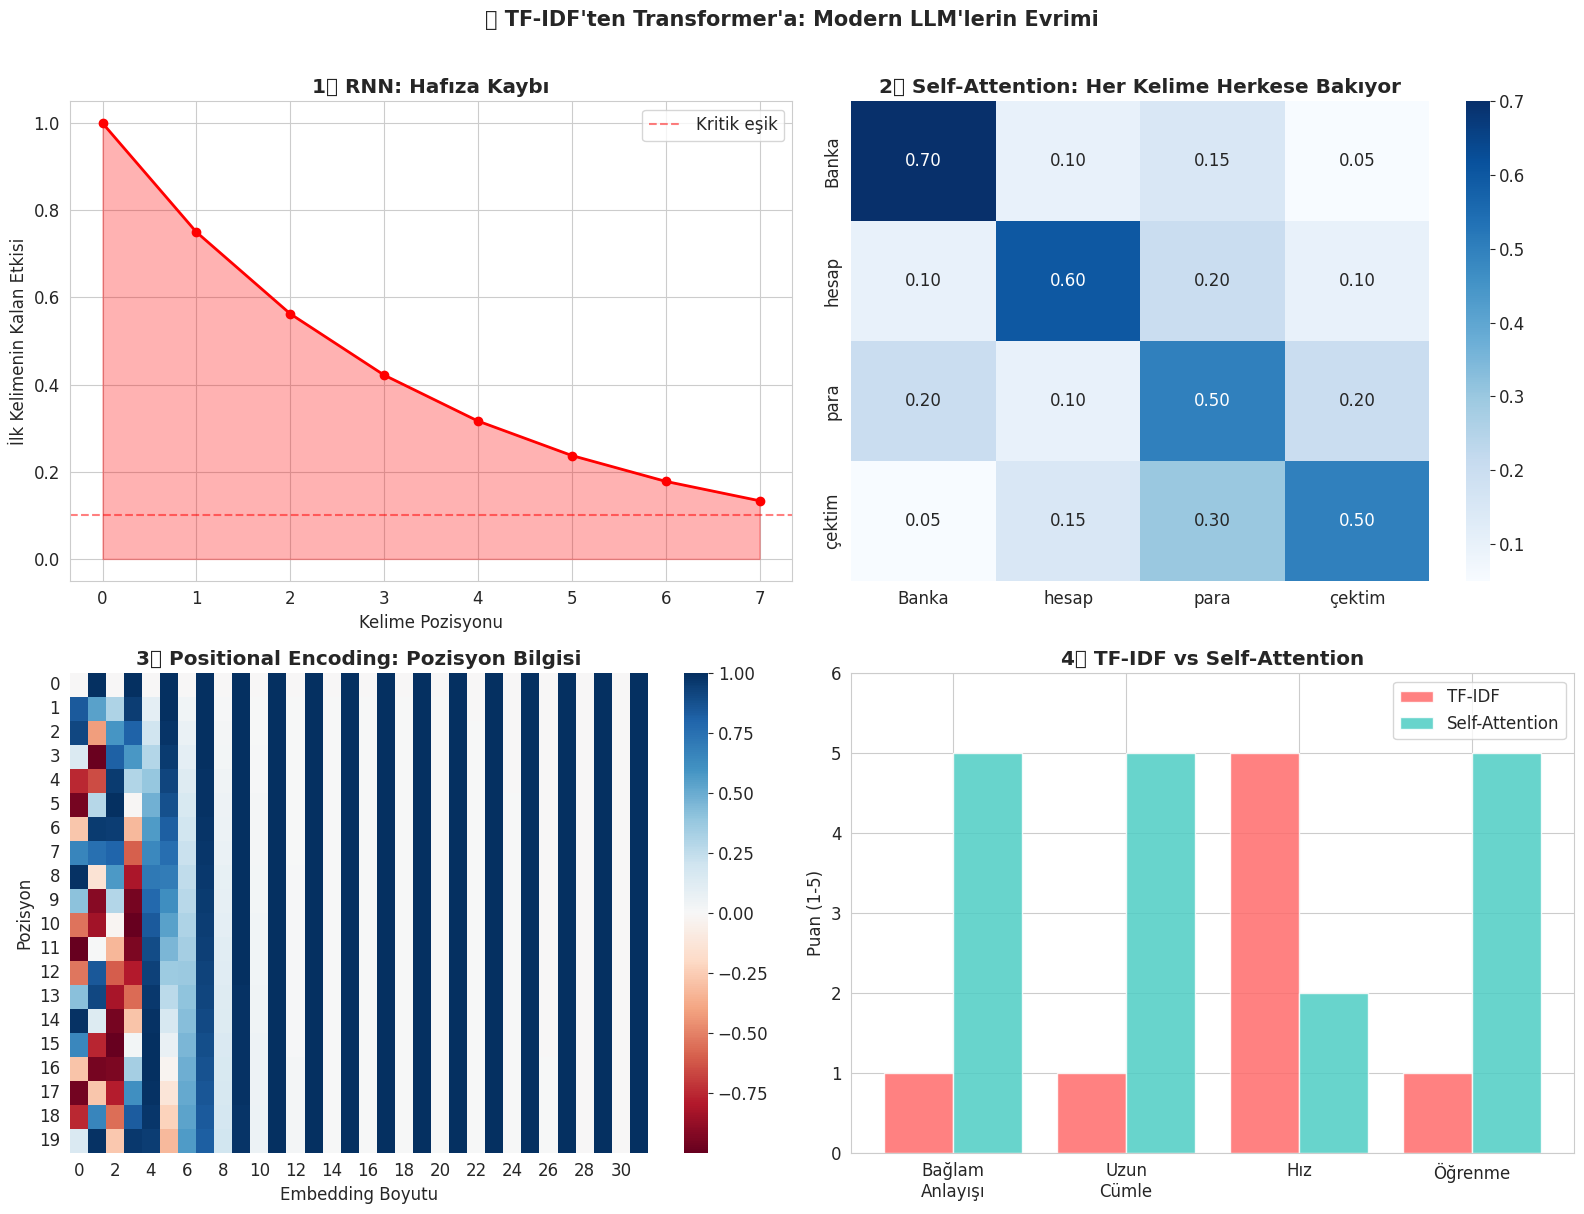

🎉 Notebook tamamlandı!

📁 Oluşturulan görseller:
   ✅ positional_encoding.png
   ✅ model_karsilastirma.png
   ✅ attention_weights.png
   ✅ multi_head_attention.png
   ✅ rnn_hafiza_kaybi.png
   ✅ ozet_pipeline.png
   ✅ tfidf_matrix.png
   ✅ tfidf_vs_attention.png
   ✅ vektor_uzayi.png
   ✅ qkv_baglam.png


In [13]:
# =============================================================================
# BONUS: Tüm kavramları tek görselde özetleyen pipeline
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. RNN hafıza kaybı ──
ax = axes[0, 0]
bozunma_arr = [0.75**i for i in range(8)]
ax.fill_between(range(8), bozunma_arr, alpha=0.3, color='red')
ax.plot(range(8), bozunma_arr, 'r-o', linewidth=2)
ax.set_title('1️⃣ RNN: Hafıza Kaybı', fontweight='bold')
ax.set_xlabel('Kelime Pozisyonu')
ax.set_ylabel('İlk Kelimenin Kalan Etkisi')
ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Kritik eşik')
ax.legend()

# ── 2. Attention matrisi örneği ──
ax = axes[0, 1]
ornek_attention = np.array([
    [0.7, 0.1, 0.15, 0.05],
    [0.1, 0.6, 0.2,  0.1 ],
    [0.2, 0.1, 0.5,  0.2 ],
    [0.05,0.15,0.3,  0.5 ]
])
sns.heatmap(ornek_attention, annot=True, fmt='.2f',
            xticklabels=['Banka','hesap','para','çektim'],
            yticklabels=['Banka','hesap','para','çektim'],
            cmap='Blues', ax=ax)
ax.set_title('2️⃣ Self-Attention: Her Kelime Herkese Bakıyor', fontweight='bold')

# ── 3. PE görselleştirmesi ──
ax = axes[1, 0]
PE_kucuk = pozisyonel_kodlama_gorsellestir(max_pos=20, d_model=32)
sns.heatmap(PE_kucuk, cmap='RdBu', center=0, ax=ax)
ax.set_title('3️⃣ Positional Encoding: Pozisyon Bilgisi', fontweight='bold')
ax.set_xlabel('Embedding Boyutu')
ax.set_ylabel('Pozisyon')

# ── 4. TF-IDF vs Attention performans karşılaştırması ──
ax = axes[1, 1]
kategoriler = ['Bağlam\nAnlayışı', 'Uzun\nCümle', 'Hız', 'Öğrenme']
tfidf_puanlar     = [1, 1, 5, 1]
attention_puanlar = [5, 5, 2, 5]

x_pos = np.arange(len(kategoriler))
ax.bar(x_pos - 0.2, tfidf_puanlar, 0.4, label='TF-IDF', color='#FF6B6B', alpha=0.85)
ax.bar(x_pos + 0.2, attention_puanlar, 0.4, label='Self-Attention', color='#4ECDC4', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(kategoriler)
ax.set_title('4️⃣ TF-IDF vs Self-Attention', fontweight='bold')
ax.set_ylabel('Puan (1-5)')
ax.legend()
ax.set_ylim(0, 6)

plt.suptitle('🧠 TF-IDF\'ten Transformer\'a: Modern LLM\'lerin Evrimi',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ozet_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

print('🎉 Notebook tamamlandı!')
print('\n📁 Oluşturulan görseller:')
import os
for f in os.listdir('.'):
    if f.endswith('.png'):
        print(f'   ✅ {f}')